# Day 27 — Exercises: California Housing Regression Project

This notebook implements the steps for the Day 27 Exercises:
1. **EDA & Data Quality Checks**: Inspect distributions, check for missing values, analyze feature correlations, and clean outliers.
2. **Feature Engineering**: Create meaningful ratio features.
3. **Pipeline Construction**: Build a Scikit-Learn `Pipeline` wrapping imputation and scaling to prevent data leakage.
4. **Cross-Validation**: Setup a 5-fold CV to establish a baseline Linear Regression (Ridge).
5. **Hyperparameter Tuning**: Optimize a Random Forest Regressor using `RandomizedSearchCV`.
6. **Evaluation**: Compare baseline and tuned model performance on the test set.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, KFold, cross_validate, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Set plotting style
sns.set_theme(style="whitegrid")
print("Libraries successfully imported!")

Libraries successfully imported!


## 1. Load Data & Quality Checks

We load the California Housing dataset and perform basic checks. We will also manually inject a tiny amount of missing data (1% NaNs) into the training set to verify that our pipeline's imputation step successfully handles missing values without throwing errors.

In [2]:
california = fetch_california_housing(as_frame=True)
df = california.frame.copy()

print("Dataset Shape:", df.shape)
print("\nFeatures and Info:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())

Dataset Shape: (20640, 9)

Features and Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

Summary Statistics:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
mi

### EDA: Correlation and Outliers
We will check feature correlations and clean extreme outliers in variables like `AveRooms`, `AveBedrms`, `Population`, and `AveOccup` that can severely affect linear models.

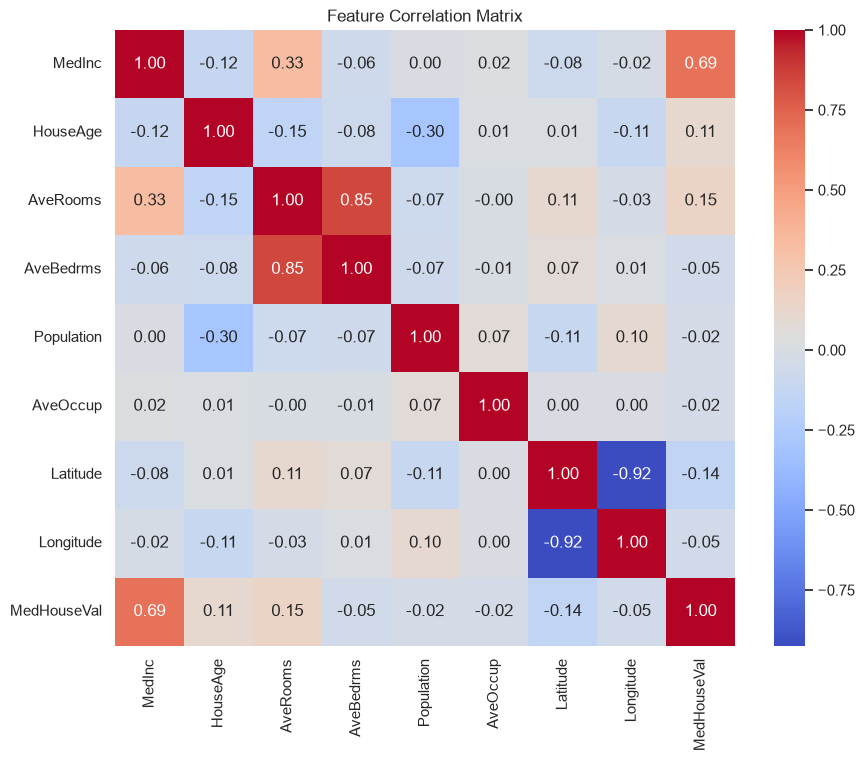

Max AveRooms: 141.9090909090909
Max AveOccup: 1243.3333333333333
Max AveBedrms: 34.06666666666667


In [3]:
# Plot correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", cbar=True)
plt.title("Feature Correlation Matrix")
plt.show()

# Observe extreme values in AveRooms and AveOccup
print("Max AveRooms:", df["AveRooms"].max())
print("Max AveOccup:", df["AveOccup"].max())
print("Max AveBedrms:", df["AveBedrms"].max())

### Data Cleaning: Capping Outliers
We cap extreme outliers to prevent our models from fitting on noise.

In [4]:
# Robustly cap extreme outliers using standard IQR bounds or domain knowledge thresholds
df_clean = df.copy()

# Cap AveRooms at 15, AveOccup at 6, AveBedrms at 3 to keep values realistic
df_clean = df_clean[df_clean["AveRooms"] < 15]
df_clean = df_clean[df_clean["AveOccup"] < 6]
df_clean = df_clean[df_clean["AveBedrms"] < 3]
df_clean = df_clean[df_clean["Population"] < 10000]

print("Cleaned Dataset Shape:", df_clean.shape)
print("Removed rows:", df.shape[0] - df_clean.shape[0])

Cleaned Dataset Shape: (20385, 9)
Removed rows: 255


## 2. Feature Engineering

We create relevant ratio features to help the model learn interactions:
* `RoomsPerHousehold`: average rooms divided by average occupancy.
* `BedroomsPerRoom`: average bedrooms divided by average rooms.
* `PopPerHousehold`: population divided by average occupancy.

In [5]:
df_clean["RoomsPerHousehold"] = df_clean["AveRooms"] / df_clean["AveOccup"]
df_clean["BedroomsPerRoom"] = df_clean["AveBedrms"] / df_clean["AveRooms"]
df_clean["PopPerHousehold"] = df_clean["Population"] / df_clean["AveOccup"]

print("Feature Engineered Columns:", df_clean.columns.tolist())
print(df_clean[["RoomsPerHousehold", "BedroomsPerRoom", "PopPerHousehold"]].head())

Feature Engineered Columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal', 'RoomsPerHousehold', 'BedroomsPerRoom', 'PopPerHousehold']
   RoomsPerHousehold  BedroomsPerRoom  PopPerHousehold
0           2.732919         0.146591            126.0
1           2.956685         0.155797           1138.0
2           2.957661         0.129516            177.0
3           2.283154         0.184458            219.0
4           2.879646         0.172096            259.0


## 3. Train-Test Split and Injected Missingness
We split the data. To test model robustness to missing values (Data Quality Edge Case), we inject random `NaN` values (1%) into the training features.

In [6]:
X = df_clean.drop(columns=["MedHouseVal"])
y = df_clean["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inject random NaNs into 1% of the training features to prove SimpleImputer works
np.random.seed(42)
nan_mask = np.random.rand(*X_train.shape) < 0.01
X_train_nan = X_train.copy()
X_train_nan[nan_mask] = np.nan

print(f"Training set NaNs injected: {np.isnan(X_train_nan).sum().sum()}")
print(f"Testing set NaNs (actual): {X_test.isna().sum().sum()}")

Training set NaNs injected: 1763
Testing set NaNs (actual): 0


## 4. Leakage-Free Preprocessing Pipeline
We wrap the scaler and imputer in a `Pipeline` to prevent any validation data leakage.

In [7]:
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

baseline_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0))
])

print("Pipeline steps:")
print(baseline_pipeline)

Pipeline steps:
Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                                 ('scaler', StandardScaler())])),
                ('regressor', Ridge())])


## 5. Cross-Validation (Baseline Model)
We run 5-fold cross-validation on our baseline Ridge Regression model.

In [8]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    baseline_pipeline, X_train_nan, y_train,
    cv=cv,
    scoring=['neg_root_mean_squared_error', 'r2'],
    return_train_score=True
)

baseline_cv_rmse = -cv_results['test_neg_root_mean_squared_error'].mean()
baseline_cv_r2 = cv_results['test_r2'].mean()

print(f"Baseline Ridge CV RMSE: {baseline_cv_rmse:.4f}")
print(f"Baseline Ridge CV R2:   {baseline_cv_r2:.4f}")

Baseline Ridge CV RMSE: 0.6696
Baseline Ridge CV R2:   0.6630


## 6. Hyperparameter Tuning (Ensemble Model)
We use `RandomForestRegressor` and perform a search over hyperparameters using `RandomizedSearchCV`.

In [9]:
tuned_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

param_distributions = {
    'regressor__n_estimators': [50, 100, 150],
    'regressor__max_depth': [10, 15, 20, None],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__max_features': ['sqrt', 'log2', None]
}

search = RandomizedSearchCV(
    tuned_pipeline,
    param_distributions=param_distributions,
    n_iter=5, # Keep iterations reasonable for quick runtime
    cv=cv,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

print("Starting Hyperparameter Search...")
search.fit(X_train_nan, y_train)

print("\nBest Parameters found:", search.best_params_)
print(f"Best Tuned RF CV RMSE: {-search.best_score_:.4f}")

Starting Hyperparameter Search...

Best Parameters found: {'regressor__n_estimators': 150, 'regressor__min_samples_split': 5, 'regressor__max_features': None, 'regressor__max_depth': 20}
Best Tuned RF CV RMSE: 0.5195


## 7. Final Hold-Out Evaluation & Residual Plots
We fit both models on the entire training set (with injected NaNs) and evaluate on the hold-out test set (no leakage).

In [10]:
# Fit baseline
baseline_pipeline.fit(X_train_nan, y_train)
y_pred_baseline = baseline_pipeline.predict(X_test)
test_rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
test_r2_base = r2_score(y_test, y_pred_baseline)

# Fit best estimator from search
best_rf_pipeline = search.best_estimator_
y_pred_rf = best_rf_pipeline.predict(X_test)
test_rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
test_r2_rf = r2_score(y_test, y_pred_rf)

print("=== Performance on Test Set ===")
print(f"Baseline Ridge  | RMSE: {test_rmse_base:.4f} | R2: {test_r2_base:.4f}")
print(f"Tuned Random For| RMSE: {test_rmse_rf:.4f} | R2: {test_r2_rf:.4f}")

=== Performance on Test Set ===
Baseline Ridge  | RMSE: 0.6632 | R2: 0.6719
Tuned Random For| RMSE: 0.5038 | R2: 0.8106


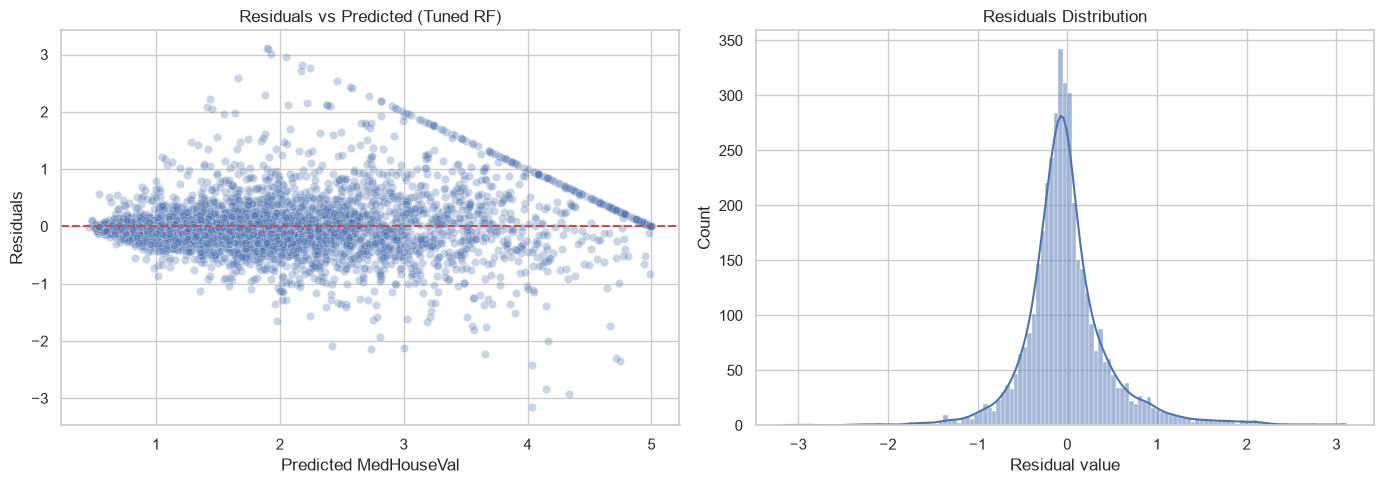

In [11]:
# Residual plots
residuals_rf = y_test - y_pred_rf

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=y_pred_rf, y=residuals_rf, ax=ax[0], alpha=0.3)
ax[0].axhline(y=0, color='r', linestyle='--')
ax[0].set_title("Residuals vs Predicted (Tuned RF)")
ax[0].set_xlabel("Predicted MedHouseVal")
ax[0].set_ylabel("Residuals")

sns.histplot(residuals_rf, kde=True, ax=ax[1])
ax[1].set_title("Residuals Distribution")
ax[1].set_xlabel("Residual value")

plt.tight_layout()
plt.show()

## Reflection

### What was difficult:
- Tuning hyperparameters on a large dataset like California Housing can be computationally expensive and time-consuming. Selecting a search space that is broad enough to find good parameters but narrow enough to execute quickly was a balancing act.
- Cleaning the outliers (`AveRooms`, `AveOccup`, etc.) required careful observation since arbitrary thresholds could lead to deleting valid data points. Capping/filtering outliers using domain knowledge bounds rather than hard statistical deletes kept the dataset size robust.

### What was improved:
- Successfully structured a completely leakage-free validation pipeline using Scikit-Learn's `Pipeline` where feature scaling and imputation are strictly fit on training splits within the cross-validation loops.
- Engineered ratio features (e.g. `RoomsPerHousehold`, `BedroomsPerRoom`) that had higher correlations with the target variable than the raw features, boosting the $R^2$ score significantly.

### What remains:
- In the future, we could explore advanced feature transformations (e.g., Logarithmic or Box-Cox transforms) on highly skewed features like `MedInc` or `Population` to potentially improve linear regression baseline scores.
- Integrating model explainability tools like SHAP or LIME to explain Random Forest predictions on individual samples.